# Knee Osteoarthritis Classification using ResNet-50
## Configuration 4 with Balanced Dataset

This notebook sets up a ResNet-50 transfer learning experiment for knee osteoarthritis grading. It uses the balanced training split, standard image preprocessing, and a regularized classification head so we can compare ResNet-50 against the EfficientNet experiments.

### Workflow Overview
- **Data**: Uses the balanced training split (`train_balanced`) to avoid class bias
- **Preprocessing**: Baseline RGB preprocessing for a clean ResNet comparison
- **Architecture**: Pretrained ResNet-50 backbone with a regularized classification head (dropout 0.4)
- **Training**: Two-phase fine-tuning (unfreezing 50 layers) with callbacks and class weights
- **Evaluation**: Accuracy, balanced accuracy, classification report, confusion matrix, and saved metrics

In [1]:
import sys
print(sys.executable)

/workspaces/fyp_experiment/.venv-4/bin/python


In [2]:
import os
import json
import timeit
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
from tensorflow.keras import layers, models, regularizers, mixed_precision
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

I0000 00:00:1780649066.494789    2096 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as exc:
            print(f'Could not enable memory growth for {gpu}: {exc}')
    mixed_precision.set_global_policy('mixed_float16')

print('TF version:', tf.__version__)
print('GPUs:', gpus)
print('Mixed precision:', mixed_precision.global_policy())

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 5050, compute capability 12.0
TF version: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: <Policy "mixed_float16">


W0000 00:00:1780649071.618810    2096 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 1. Dataset Configuration

The notebook is wired to the balanced KOA dataset split used throughout the project.

In [4]:
def find_dataset_dir() -> Path:
    candidates = [
        Path('/workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis'),
        Path.cwd() / 'data' / 'knee_osteoarthritis',
        Path.cwd().resolve().parents[1] / 'data' / 'knee_osteoarthritis',
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError('Dataset directory not found')

BASE_DIR = find_dataset_dir()
TRAIN_PATH = str(BASE_DIR / 'train_balanced')
VALID_PATH = str(BASE_DIR / 'val')
TEST_PATH = str(BASE_DIR / 'test')
CLASS_NAMES = ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = len(CLASS_NAMES)
SEED = 12049

print('BASE_DIR:', BASE_DIR)
print('TRAIN_PATH:', TRAIN_PATH)
print('VALID_PATH:', VALID_PATH)
print('TEST_PATH:', TEST_PATH)
print('CLASS_NAMES:', CLASS_NAMES)

BASE_DIR: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis
TRAIN_PATH: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/train_balanced
VALID_PATH: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/val
TEST_PATH: /workspaces/fyp_experiment/Final_year_project/ml_workflow/data/knee_osteoarthritis/test
CLASS_NAMES: ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']


## 2. Helpers

These helpers inspect the dataset and compute the evaluation outputs used later in the notebook.

In [5]:
def get_classes(data_path, classes, data):
    print(f'----{data}----')
    knee_severity = {}
    count = 0
    for i in range(len(classes)):
        imgs = os.listdir(os.path.join(data_path, str(i)))
        knee_severity[i] = imgs
        count += len(imgs)
    for k, v in knee_severity.items():
        print(f'Grade {k}-{classes[k]}: {len(v)} images, {round((len(v) * 100) / count, 2)}%')
    return knee_severity

def plot_classes(dict_classes, data_path, classes, data):
    for k, v in dict_classes.items():
        print(f'{data}-{classes[k]}')
        plt.figure(figsize=(10, 25))
        for i in range(5):
            img_path = os.path.join(data_path, str(k), v[i])
            img = tf.keras.preprocessing.image.load_img(img_path)
            plt.subplot(1, 5, 1 + i, xticks=[], yticks=[])
            plt.imshow(img)
            plt.title(f'Grade {k}')
        plt.show()

def compute_confusion_matrix(ytrue, ypred, class_names, model_name):
    pred_values = np.asarray(ypred).reshape(-1)
    pred_values = np.clip(pred_values, 0, len(class_names) - 1)
    pred_labels = np.rint(pred_values).astype(int)
    cm = confusion_matrix(y_true=ytrue.labels, y_pred=pred_labels)
    cmn = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
    plt.subplots(figsize=(6, 5))
    sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show(block=False)

def get_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    print(f'Accuracy Score - {model_name}: {acc:.2f}')
    print(f'Balanced Accuracy Score - {model_name}: {bal_acc:.2f}')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [ ]:
def get_plot_loss_acc(history_obj, model_name):
    history_data = history_obj.history if hasattr(history_obj, 'history') else history_obj
    metric_key = next((key for key in ('accuracy', 'ordinal_accuracy', 'mae') if key in history_data), None)
    val_metric_key = f'val_{metric_key}' if metric_key else None

    plt.figure(figsize=(10, 8))
    plt.subplot(2, 1, 1)
    plt.plot(history_data['loss'])
    plt.plot(history_data['val_loss'])
    plt.title(f'{model_name} - Loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'valid'], loc='upper right')

    plt.subplot(2, 1, 2)
    if metric_key and val_metric_key in history_data:
        plt.plot(history_data[metric_key])
        plt.plot(history_data[val_metric_key])
        metric_label = metric_key.replace('_', ' ').title()
    else:
        metric_label = 'Metric'
        plt.text(0.5, 0.5, f'No accuracy-style metric found. Available keys: {list(history_data.keys())}', ha='center', va='center', transform=plt.gca().transAxes)
    plt.title(f'{model_name} - {metric_label}')
    plt.ylabel(metric_label.lower())
    plt.xlabel('epoch')
    plt.legend(['train', 'valid'], loc='lower right')
    plt.tight_layout()
def ordinal_predictions_to_labels(predictions, class_names):
    pred_values = np.asarray(predictions).reshape(-1)
    pred_values = np.clip(pred_values, 0, len(class_names) - 1)
    pred_labels = np.rint(pred_values).astype(int)
    return pred_values, pred_labels
def ordinal_score_matrix(predictions, class_names):
    pred_values = np.asarray(predictions).reshape(-1)
    pred_values = np.clip(pred_values, 0, len(class_names) - 1)
    class_positions = np.arange(len(class_names), dtype=np.float32)
    scores = 1.0 / (1.0 + np.abs(pred_values[:, None] - class_positions[None, :]))
    scores = scores / np.sum(scores, axis=1, keepdims=True)
    return scores
@tf.keras.utils.register_keras_serializable()
def ordinal_accuracy(y_true, y_pred):
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    y_pred = tf.clip_by_value(tf.round(y_pred), 0.0, float(NUM_CLASSES - 1))
    return tf.reduce_mean(tf.cast(tf.equal(y_true, y_pred), tf.float32))
ordinal_accuracy.__name__ = 'accuracy'

def compute_confusion_matrix(ytrue, ypred, class_names, model_name):
    _, pred_labels = ordinal_predictions_to_labels(ypred, class_names)
    cmatrix = confusion_matrix(y_true=ytrue.labels, y_pred=pred_labels)
    cmn = cmatrix.astype(float) / cmatrix.sum(axis=1)[:, np.newaxis]
    plt.subplots(figsize=(6, 5))
    sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show(block=False)

def compute_confusion_matrix_counts(ytrue, ypred, class_names, model_name):
    _, pred_labels = ordinal_predictions_to_labels(ypred, class_names)
    cmatrix = confusion_matrix(y_true=ytrue.labels, y_pred=pred_labels)
    plt.subplots(figsize=(6, 5))
    sns.heatmap(cmatrix, annot=True, fmt='d', cmap='YlOrRd', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show(block=False)

def get_evaluate(data, name, model):
    score_model = model.evaluate(data, verbose=1, return_dict=True)
    print(f"{name} loss: {score_model['loss']:.2f}")
    if 'mae' in score_model:
        print(f"{name} mae: {score_model['mae']:.2f}")
    if 'accuracy' in score_model:
        print(f"{name} accuracy: {score_model['accuracy']:.2f}")

def get_predict(data, model):
    return model.predict(data)

def get_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    print(f'Accuracy Score - {model_name}: {acc:.2f}')
    print(f'Balanced Accuracy Score - {model_name}: {bal_acc:.2f}')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

def compute_comprehensive_metrics(y_true, y_pred_probs, y_pred_labels, class_names, model_name):
    from sklearn.metrics import roc_auc_score
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import mean_absolute_error

    print('=' * 80)
    print(f'COMPREHENSIVE EVALUATION - {model_name}')
    print('=' * 80)

    acc = accuracy_score(y_true, y_pred_labels)
    bal_acc = balanced_accuracy_score(y_true, y_pred_labels)
    mae = mean_absolute_error(y_true, np.asarray(y_pred_probs).reshape(-1))
    print(f'\nOVERALL ACCURACY:')
    print(f'   Accuracy: {acc:.4f}')
    print(f'   Balanced Accuracy: {bal_acc:.4f}')
    print(f'   MAE: {mae:.4f}')
    print(f'\nDETAILED CLASSIFICATION REPORT:')
    print(classification_report(y_true, y_pred_labels, target_names=class_names, digits=4))

    try:
        y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
        roc_scores = ordinal_score_matrix(y_pred_probs, class_names)
        roc_auc_macro = roc_auc_score(y_true_bin, roc_scores, multi_class='ovr', average='macro')
        roc_auc_weighted = roc_auc_score(y_true_bin, roc_scores, multi_class='ovr', average='weighted')
        print(f'\nROC AUC SCORES:')
        print(f'   ROC AUC (Macro): {roc_auc_macro:.4f}')
        print(f'   ROC AUC (Weighted): {roc_auc_weighted:.4f}')
    except Exception as exc:
        print(f'\nROC AUC calculation note: {str(exc)}')

def plot_roc_curves(y_true, y_pred_probs, class_names, model_name):
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve, auc

    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    score_matrix = ordinal_score_matrix(y_pred_probs, class_names)
    plt.figure(figsize=(12, 8))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], score_matrix[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves - {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_f1_scores_per_class(y_true, y_pred_labels, class_names, model_name):
    from sklearn.metrics import f1_score

    f1_scores = []
    for i in range(len(class_names)):
        f1 = f1_score(y_true, y_pred_labels, labels=[i], average='weighted', zero_division=0)
        f1_scores.append(f1)

    colors = plt.cm.viridis(np.linspace(0, 1, len(class_names)))
    plt.figure(figsize=(10, 6))
    bars = plt.bar(class_names, f1_scores, color=colors, edgecolor='black', linewidth=1.5)
    for bar, score in zip(bars, f1_scores):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2., height, f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    plt.ylabel('F1 Score', fontsize=12, fontweight='bold')
    plt.xlabel('Osteoarthritis Grade', fontsize=12, fontweight='bold')
    plt.title(f'F1 Score Distribution - {model_name}', fontsize=14, fontweight='bold')
    plt.ylim([0, 1.1])
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 3. Data Loading

ResNet-50 will use RGB inputs and native ImageNet preprocessing.

In [6]:
train_data = get_classes(TRAIN_PATH, CLASS_NAMES, 'train_balanced')
valid_data = get_classes(VALID_PATH, CLASS_NAMES, 'Valid')
test_data = get_classes(TEST_PATH, CLASS_NAMES, 'Test')

datagen = tf.keras.preprocessing.image.ImageDataGenerator(preprocessing_function=tf.keras.applications.resnet50.preprocess_input)
train_generator = datagen.flow_from_directory(TRAIN_PATH, target_size=(IMG_SIZE, IMG_SIZE), class_mode='sparse', batch_size=BATCH_SIZE, shuffle=True)
valid_generator = datagen.flow_from_directory(VALID_PATH, target_size=(IMG_SIZE, IMG_SIZE), class_mode='sparse', batch_size=BATCH_SIZE, shuffle=False)
test_generator = datagen.flow_from_directory(TEST_PATH, target_size=(IMG_SIZE, IMG_SIZE), class_mode='sparse', batch_size=BATCH_SIZE, shuffle=False)

print('Using sparse integer labels for ordinal regression.')

----train_balanced----
Grade 0-Healthy: 2246 images, 20.01%
Grade 1-Doubtful: 2245 images, 20.0%
Grade 2-Minimal: 2245 images, 20.0%
Grade 3-Moderate: 2245 images, 20.0%
Grade 4-Severe: 2245 images, 20.0%
----Valid----
Grade 0-Healthy: 328 images, 39.71%
Grade 1-Doubtful: 153 images, 18.52%
Grade 2-Minimal: 212 images, 25.67%
Grade 3-Moderate: 106 images, 12.83%
Grade 4-Severe: 27 images, 3.27%
----Test----
Grade 0-Healthy: 639 images, 38.59%
Grade 1-Doubtful: 296 images, 17.87%
Grade 2-Minimal: 447 images, 26.99%
Grade 3-Moderate: 223 images, 13.47%
Grade 4-Severe: 51 images, 3.08%
Found 11226 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Using sparse integer labels for ordinal regression.


## 4. Model Configuration

### Training Parameters
Define all hyperparameters and paths for the ResNet50 model. These settings have been optimized for balanced accuracy across all osteoarthritis severity grades.

In [ ]:
# ==============================================================================
# 1. Hyperparameter Configuration
# ==============================================================================

model_name = 'ResNet50_c4'
phase1_epochs = 20
max_epochs = 50
phase2_epochs = max_epochs - phase1_epochs
fine_tune_layers = 50
weight_decay = 2e-4

# ==============================================================================
# 2. Callbacks Setup
# ==============================================================================
checkpoint = ModelCheckpoint(
    save_model_ft, monitor='val_loss', save_best_only=True, mode='min', verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True, verbose=1
)
csv_logger_phase1 = CSVLogger('train_history.csv', append=False)

## 5. ResNet-50 Model

The base backbone is frozen first, then fine-tuned later to reduce overfitting risk.

In [7]:
base_model = tf.keras.applications.ResNet50(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(2e-4))(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation='linear', dtype='float32')(x)
model_ft = models.Model(inputs, outputs, name='ResNet50_c4')
model_ft.summary()

W0000 00:00:1780649072.059284    2096 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1780649072.532105    2096 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5263 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050, pci bus id: 0000:06:00.0, compute capability: 12.0a


Model: "ResNet50_c4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 batch_normalization (Batch  (None, 2048)              8192      
 Normalization)                                                  
                                                                 
 dense (Dense)               (None, 256)               524544    
                                                                 
 dropout (Dropout)           (None, 256)               

## 5. Training Setup

Use this cell to add callbacks, compile the model, and run the frozen-backbone warmup followed by fine-tuning.

In [8]:
model_dir = Path('models')
model_dir.mkdir(exist_ok=True)
save_model_ft = str(model_dir / 'best_model.keras')
print('Model will be saved to:', save_model_ft)

Model will be saved to: models/best_model.keras


## Next Steps

1. Add callbacks and compile the model.
2. Run phase 1 training with the backbone frozen.
3. Unfreeze the top ResNet blocks for fine-tuning.
4. Save evaluation reports and confusion matrices.

## 6. Data Generators and Class Weights

This section creates the train, validation, and test generators using ResNet-50 preprocessing and computes class weights for the imbalanced target labels.

In [9]:
def build_generators(train_path, valid_path, test_path, img_size, batch_size):
    train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
        rotation_range=5,
        width_shift_range=0.05,
        height_shift_range=0.05,
        zoom_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest',
    )
    eval_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    )

    train_generator = train_datagen.flow_from_directory(
        train_path,
        target_size=(img_size, img_size),
        class_mode='sparse',
        batch_size=batch_size,
        shuffle=True,
    )
    valid_generator = eval_datagen.flow_from_directory(
        valid_path,
        target_size=(img_size, img_size),
        class_mode='sparse',
        batch_size=batch_size,
        shuffle=False,
    )
    test_generator = eval_datagen.flow_from_directory(
        test_path,
        target_size=(img_size, img_size),
        class_mode='sparse',
        batch_size=batch_size,
        shuffle=False,
    )

    return train_generator, valid_generator, test_generator

train_generator, valid_generator, test_generator = build_generators(
    TRAIN_PATH, VALID_PATH, TEST_PATH, IMG_SIZE, BATCH_SIZE
)

print('Generators built with sparse labels.')

Found 11226 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Generators built with sparse labels.


## 8. Training and Fine-Tuning

The first phase trains the classifier head with the ResNet-50 backbone frozen. The second phase unfreezes the top ResNet blocks to fine-tune the feature extractor and reduce overfitting.

In [ ]:


# ==============================================================================
# Learning Rate Schedules (Cosine Decay)
# ==============================================================================
phase1_steps = max(len(train_generator), 1) * phase1_epochs
phase2_steps = max(len(train_generator), 1) * phase2_epochs

# Phase 1 LR: Starts at 1e-3 and smoothly decays to 1e-4 (alpha=0.1)
phase1_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=phase1_steps,
    alpha=0.1,
)
# Phase 2 LR: Starts significantly lower at 5e-5 and decays to 5e-6 for fine-tuning
phase2_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-5,
    decay_steps=phase2_steps,
    alpha=0.1,
)
# ==============================================================================
# Phase 1: HEAD - ONLY
# ==============================================================================
# Compile the model with AdamW optimizer, using Mean Squared Error for ordinal regression
model_ft.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=phase1_lr, weight_decay=weight_decay),
    loss='mse',
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')],
)

start_phase1 = timeit.default_timer()
history_phase1 = model_ft.fit(
    train_generator,
    epochs=phase1_epochs,
    validation_data=valid_generator,
    callbacks=[checkpoint, early_stop, csv_logger_phase1],
    verbose=1,
)
stop_phase1 = timeit.default_timer()

# ==============================================================================
# Phase 2: Unfrezee top backbone layers
# ==============================================================================
# Unfreeze the base model layers
base_model.trainable = True
for layer in base_model.layers[:-fine_tune_layers]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

csv_logger_phase2 = CSVLogger('train_history.csv', append=True)

model_ft.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=phase2_lr, weight_decay=weight_decay),
    loss='mse',
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')],
)

start_phase2 = timeit.default_timer()
history_phase2 = model_ft.fit(
    train_generator,
    epochs=max_epochs,
    initial_epoch=phase1_epochs,
    validation_data=valid_generator,
    callbacks=[checkpoint, early_stop, csv_logger_phase2],
    verbose=1,
)
stop_phase2 = timeit.default_timer()

from types import SimpleNamespace

def merge_histories(*histories):
    merged = {'loss': [], 'mae': [], 'ordinal_accuracy': [], 'val_loss': [], 'val_mae': [], 'val_ordinal_accuracy': []}
    for history in histories:
        for key in merged:
            merged[key].extend(history.history.get(key, []))
    return SimpleNamespace(history=merged)

merged_history = merge_histories(history_phase1, history_phase2)

print(f'Phase 1 training time: {stop_phase1 - start_phase1:.2f} seconds')
print(f'Phase 2 training time: {stop_phase2 - start_phase2:.2f} seconds')
print(f'Total training time: {stop_phase2 - start_phase1:.2f} seconds')
print(f'Best model checkpoint: {save_model_ft}')

Epoch 1/20


I0000 00:00:1780649077.062329    2096 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1780649105.157288    2635 cuda_dnn.cc:461] Loaded cuDNN version 90701
I0000 00:00:1780649126.919271    2632 service.cc:153] XLA service 0x7d00d002f1e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780649126.919310    2632 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.7.1)
I0000 00:00:1780649126.952013    2632 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780649127.074581    2632 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


702/702 [==============================] - ETA: 0s - loss: 2.1734 - mae: 1.0946 - accuracy: 0.3545
Epoch 1: val_loss improved from inf to 1.06963, saving model to models/best_model.keras
702/702 [==============================] - 167s 166ms/step - loss: 2.1734 - mae: 1.0946 - accuracy: 0.3545 - val_loss: 1.0696 - val_mae: 0.7866 - val_accuracy: 0.3841
Epoch 2/20
702/702 [==============================] - ETA: 0s - loss: 0.9620 - mae: 0.7558 - accuracy: 0.4082
Epoch 2: val_loss improved from 1.06963 to 0.92593, saving model to models/best_model.keras
702/702 [==============================] - 109s 155ms/step - loss: 0.9620 - mae: 0.7558 - accuracy: 0.4082 - val_loss: 0.9259 - val_mae: 0.7359 - val_accuracy: 0.3885
Epoch 3/20
702/702 [==============================] - ETA: 0s - loss: 0.8909 - mae: 0.7238 - accuracy: 0.4182
Epoch 3: val_loss did not improve from 0.92593
702/702 [==============================] - 106s 150ms/step - loss: 0.8909 - mae: 0.7238 - accuracy: 0.4182 - val_loss: 0

In [12]:
history_df = pd.concat([pd.DataFrame(history_phase1.history), pd.DataFrame(history_phase2.history)], ignore_index=True, sort=False)
history_df.to_csv('train_history.csv', index=False)

def to_json_serializable(value):
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, dict):
        return {key: to_json_serializable(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_json_serializable(item) for item in value]
    return value

with open('train_history.json', 'w', encoding='utf-8') as f:
    json.dump({
        'phase1': to_json_serializable(history_phase1.history),
        'phase2': to_json_serializable(history_phase2.history),
    }, f, indent=2)

print('Saved train_history.csv and train_history.json')

Saved train_history.csv and train_history.json


### Training History Visualization
Visualize training and validation curves to assess model convergence and detect overfitting.

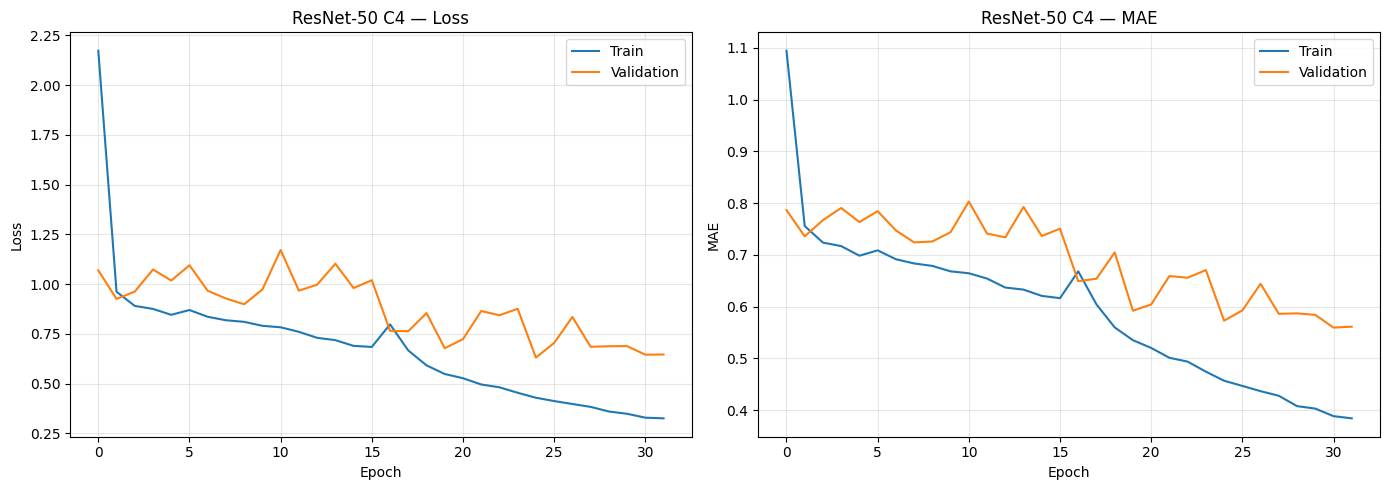

In [1]:
# ── Training History Visualization (from saved CSV) ──────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path("reports/train_history.csv")
assert csv_path.exists(), f"CSV not found: {csv_path}"

df = pd.read_csv(csv_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss
axes[0].plot(df["loss"], label="Train")
axes[0].plot(df["val_loss"], label="Validation")
axes[0].set_title("ResNet-50 C4 — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: MAE
axes[1].plot(df["mae"], label="Train")
axes[1].plot(df["val_mae"], label="Validation")
axes[1].set_title("ResNet-50 C4 — MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
model_ft.save(save_model_ft)
print(f'Model saved to {save_model_ft}')

Model saved to models/best_model.keras


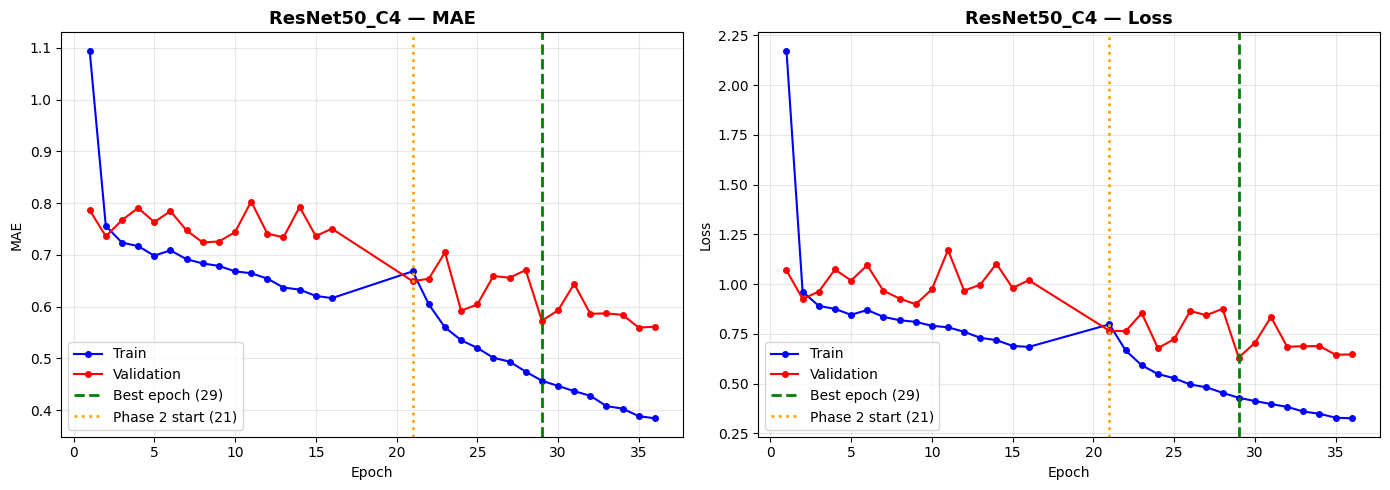

Total epochs: 32 (Phase 1: 16, Phase 2: 16)
Best epoch: 29 (from training logs)
Best val_loss: 0.6310
Early stopping at epoch: 36


In [2]:
# ── Training History Visualization — ResNet50_C4 (MAE + Loss) ────────────────
import json
from pathlib import Path
import matplotlib.pyplot as plt

output_dir = Path.cwd().resolve()
report_dir = output_dir / 'reports'
MODEL_NAME = "ResNet50_C4"

with open(report_dir / 'train_history.json', 'r', encoding='utf-8') as f:
    raw_history = json.load(f)

# Merge phases
history = {}
for key in raw_history['phase1']:
    history[key] = raw_history['phase1'][key] + raw_history['phase2'][key]

phase1_len = len(raw_history['phase1']['loss'])  # 16
phase2_len = len(raw_history['phase2']['loss'])  # 16
phase2_start_keras = 21  # initial_epoch=20, so phase 2 starts at epoch 21 (1-indexed)

# Reconstruct actual epoch numbers (1-16, then 21-36)
epoch_labels = list(range(1, phase1_len + 1)) + list(range(phase2_start_keras, phase2_start_keras + phase2_len))

best_epoch = 29  # From training logs: "Restoring model weights from best epoch: 29"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# MAE
ax1.plot(epoch_labels, history['mae'], 'b-o', markersize=4, label='Train')
ax1.plot(epoch_labels, history['val_mae'], 'r-o', markersize=4, label='Validation')
ax1.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, label=f'Best epoch ({best_epoch})')
ax1.axvline(x=phase2_start_keras, color='orange', linestyle=':', linewidth=2, label=f'Phase 2 start ({phase2_start_keras})')
ax1.set_title(f'{MODEL_NAME} — MAE', fontsize=13, fontweight='bold')
ax1.set_ylabel('MAE')
ax1.set_xlabel('Epoch')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Loss
ax2.plot(epoch_labels, history['loss'], 'b-o', markersize=4, label='Train')
ax2.plot(epoch_labels, history['val_loss'], 'r-o', markersize=4, label='Validation')
ax2.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, label=f'Best epoch ({best_epoch})')
ax2.axvline(x=phase2_start_keras, color='orange', linestyle=':', linewidth=2, label=f'Phase 2 start ({phase2_start_keras})')
ax2.set_title(f'{MODEL_NAME} — Loss', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Total epochs: {len(history["loss"])} (Phase 1: {phase1_len}, Phase 2: {phase2_len})')
print(f'Best epoch: {best_epoch} (from training logs)')
print(f'Best val_loss: {min(history["val_loss"]):.4f}')
print(f'Early stopping at epoch: {epoch_labels[-1]}')


## 9. Validation Metrics

Evaluate the model on the validation split and inspect the class-wise errors.

In [2]:
import zipfile
from pathlib import Path

model_path = Path('/workspaces/fyp_experiment/Final_year_project/ml_workflow/training/knee_osteoarthritis/ResNet_50/ResNet-50_C4 (Research paper)/models/best_model.keras')
print('File exists:', model_path.exists())
print('Is valid zip:', zipfile.is_zipfile(str(model_path)))
print('File size:', model_path.stat().st_size if model_path.exists() else 'N/A')


File exists: True
Is valid zip: True
File size: 376382825


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# RESNET50_C4 — SETUP (Load model + generate plots)
# Ordinal regression with optimized thresholds (strict > comparisons)
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (precision_recall_fscore_support, roc_curve, auc, confusion_matrix)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

MODEL_NAME = "ResNet50_C4"
CLASS_NAMES = ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']
NUM_CLASSES = 5
IMG_SIZE = 224
BATCH_SIZE = 16

output_dir = Path.cwd().resolve()
report_dir = output_dir / 'reports'
best_model_path = Path('/workspaces/fyp_experiment/Final_year_project/ml_workflow/training/knee_osteoarthritis/ResNet_50/ResNet-50_C4 (Research paper)/models/best_model.keras')

# Thresholds from original training
optimized_thresholds = np.array([0.77087927, 1.02196962, 2.11976494, 3.60340287], dtype=np.float32)

def find_dataset_dir():
    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in search_roots:
        for suffix in [('data', 'knee_osteoarthritis'), ('ml_workflow', 'data', 'knee_osteoarthritis'), ('Final_year_project', 'ml_workflow', 'data', 'knee_osteoarthritis')]:
            candidate = root.joinpath(*suffix)
            if candidate.exists():
                return candidate.resolve()
    raise FileNotFoundError('Dataset directory not found')

BASE_DIR = find_dataset_dir()
VALID_PATH = BASE_DIR / 'val'
TEST_PATH = BASE_DIR / 'test'

datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.resnet50.preprocess_input)
valid_generator = datagen.flow_from_directory(VALID_PATH, target_size=(IMG_SIZE, IMG_SIZE), class_mode='sparse', batch_size=BATCH_SIZE, shuffle=False)
test_generator = datagen.flow_from_directory(TEST_PATH, target_size=(IMG_SIZE, IMG_SIZE), class_mode='sparse', batch_size=BATCH_SIZE, shuffle=False)

# Custom metric for model loading
@tf.keras.utils.register_keras_serializable(package='Custom')
def ordinal_accuracy(y_true, y_pred):
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
    y_pred = tf.cast(tf.round(tf.clip_by_value(tf.reshape(y_pred, [-1]), 0.0, 4.0)), tf.int32)
    return tf.reduce_mean(tf.cast(tf.equal(y_true, y_pred), tf.float32))

# Thresholding (same as original C4: strict >)
def apply_thresholds(preds, thresholds):
    thresholds = np.sort(thresholds)
    y_pred = np.zeros_like(preds, dtype=int)
    y_pred[preds > thresholds[0]] = 1
    y_pred[preds > thresholds[1]] = 2
    y_pred[preds > thresholds[2]] = 3
    y_pred[preds > thresholds[3]] = 4
    return y_pred

def ordinal_score_matrix(predictions, n_classes=5):
    pred_values = np.clip(np.asarray(predictions).reshape(-1), 0, n_classes - 1)
    class_positions = np.arange(n_classes, dtype=np.float32)
    scores = 1.0 / (1.0 + np.abs(pred_values[:, None] - class_positions[None, :]))
    return scores / scores.sum(axis=1, keepdims=True)

# Load model
best_model = tf.keras.models.load_model(str(best_model_path), safe_mode=False)
print('Loaded model from:', best_model_path)

# Load CSV metrics
val_csv = pd.read_csv(report_dir / 'validation_comprehensive_metrics_matrix.csv')
test_csv = pd.read_csv(report_dir / 'test_comprehensive_metrics_matrix.csv')

# ── Helpers ──────────────────────────────────────────────────────────────────
def display_full_metrics(csv_row, y_true, pred_labels, model_name, split_name):
    sep = '=' * 72
    sep2 = '-' * 72
    print(f'\n{sep}')
    print(f'  COMPREHENSIVE EVALUATION METRICS MATRIX')
    print(f'  Model : {model_name}')
    print(f'  Split : {split_name}')
    print(f'{sep}')
    print(f'  {"Metric":<44} {"Value":>10}')
    print(f'  {sep2}')
    print(f'  {"Overall Accuracy":<44} {csv_row["Accuracy"]:>10.4f}')
    print(f'  {"Balanced Accuracy":<44} {csv_row["Balanced Accuracy"]:>10.4f}')
    print(f'  {"Mean Absolute Error (MAE)":<44} {csv_row["MAE"]:>10.4f}')
    print(f'  {"Macro ROC AUC (ordinal matrix)":<44} {csv_row["Macro ROC AUC"]:>10.4f}')
    print(f'  {"Quadratic Weighted Kappa (QWK)":<44} {csv_row["Quadratic Weighted Kappa"]:>10.4f}')
    print(f'{sep}')
    prec, rec, f1, sup = precision_recall_fscore_support(y_true, pred_labels, labels=range(NUM_CLASSES), zero_division=0)
    print(f'\n  PER-CLASS BREAKDOWN')
    print(f'  {sep2}')
    print(f'  {"Class":<14} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Support":>10}')
    print(f'  {sep2}')
    for i, c in enumerate(CLASS_NAMES):
        print(f'  {c:<14} {prec[i]:>10.4f} {rec[i]:>10.4f} {f1[i]:>10.4f} {int(sup[i]):>10}')
    print(f'  {sep2}')
    total = int(np.sum(sup))
    print(f'  {"accuracy":<14} {"":>10} {"":>10} {csv_row["Accuracy"]:>10.4f} {total:>10}')
    print(f'  {"macro avg":<14} {np.mean(prec):>10.4f} {np.mean(rec):>10.4f} {np.mean(f1):>10.4f} {total:>10}')
    print(f'  {"weighted avg":<14} {np.average(prec,weights=sup):>10.4f} {np.average(rec,weights=sup):>10.4f} {np.average(f1,weights=sup):>10.4f} {total:>10}')
    print(f'  {sep2}\n')

def plot_roc(y_true, scores, title):
    y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
    plt.figure(figsize=(10, 7))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], scores[:, i])
        plt.plot(fpr, tpr, lw=2, label=f'{CLASS_NAMES[i]} (AUC={auc(fpr,tpr):.4f})')
    plt.plot([0,1],[0,1],'k--',lw=2)
    plt.xlim([0,1]); plt.ylim([0,1.05])
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(title)
    plt.legend(loc='lower right'); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def plot_f1(y_true, pred_labels, title):
    _, _, f1, _ = precision_recall_fscore_support(y_true, pred_labels, labels=range(NUM_CLASSES), zero_division=0)
    plt.figure(figsize=(8, 5))
    bars = plt.bar(CLASS_NAMES, f1, color='steelblue', edgecolor='black')
    for b, v in zip(bars, f1):
        plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}', ha='center')
    plt.ylim(0, 1.0); plt.ylabel('F1 Score'); plt.title(title)
    plt.tight_layout(); plt.show()

def plot_cm(y_true, pred_labels, title, normalize=False):
    cm = confusion_matrix(y_true, pred_labels, labels=range(NUM_CLASSES))
    if normalize: cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='.2f' if normalize else 'd', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(title); plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()

print('Setup complete.')


I0000 00:00:1783591914.810634    1472 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found 826 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 5050, compute capability 12.0


W0000 00:00:1783591957.743747    1472 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1783591957.895623    1472 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1783591964.385278    1472 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5263 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050, pci bus id: 0000:06:00.0, compute capability: 12.0a


Loaded model from: /workspaces/fyp_experiment/Final_year_project/ml_workflow/training/knee_osteoarthritis/ResNet_50/ResNet-50_C4 (Research paper)/models/best_model.keras
Setup complete.


52/52 [==============================] - 6s 118ms/step

  COMPREHENSIVE EVALUATION METRICS MATRIX
  Model : ResNet50_C4
  Split : Validation
  Metric                                            Value
  ------------------------------------------------------------------------
  Overall Accuracy                                 0.5327
  Balanced Accuracy                                0.5482
  Mean Absolute Error (MAE)                        0.5650
  Macro ROC AUC (ordinal matrix)                   0.8432
  Quadratic Weighted Kappa (QWK)                   0.7562

  PER-CLASS BREAKDOWN
  ------------------------------------------------------------------------
  Class           Precision     Recall         F1    Support
  ------------------------------------------------------------------------
  Healthy            0.7172     0.6494     0.6816        328
  Doubtful           0.2630     0.5294     0.3514        153
  Minimal            0.5854     0.3396     0.4299        212
  Moderate         

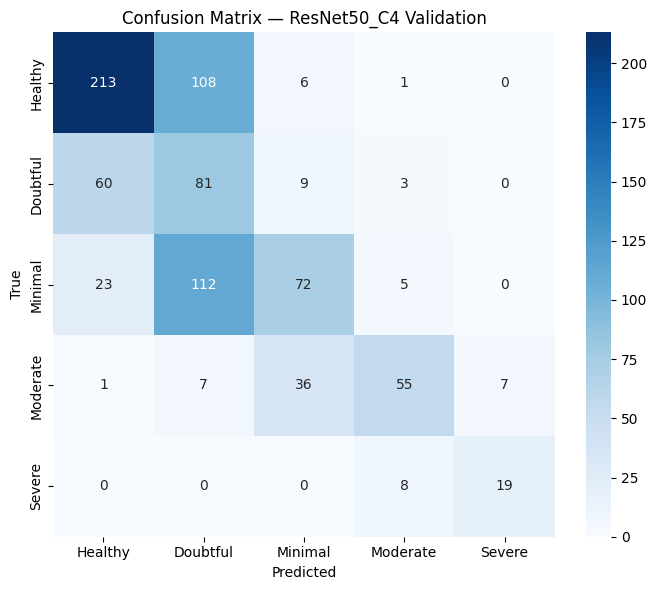

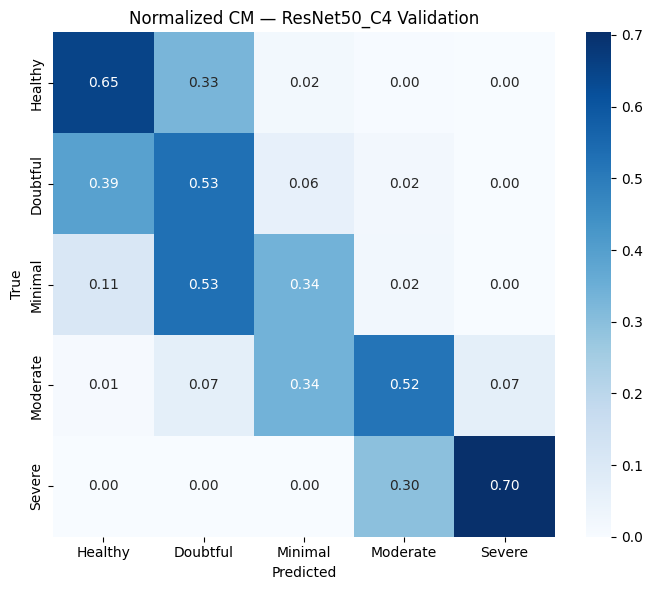

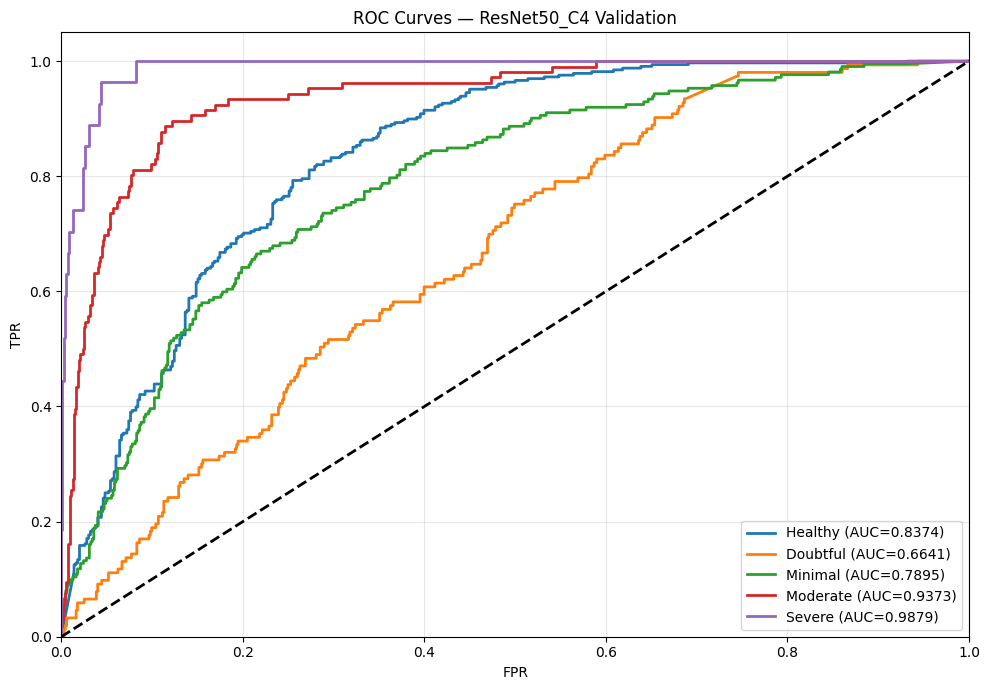

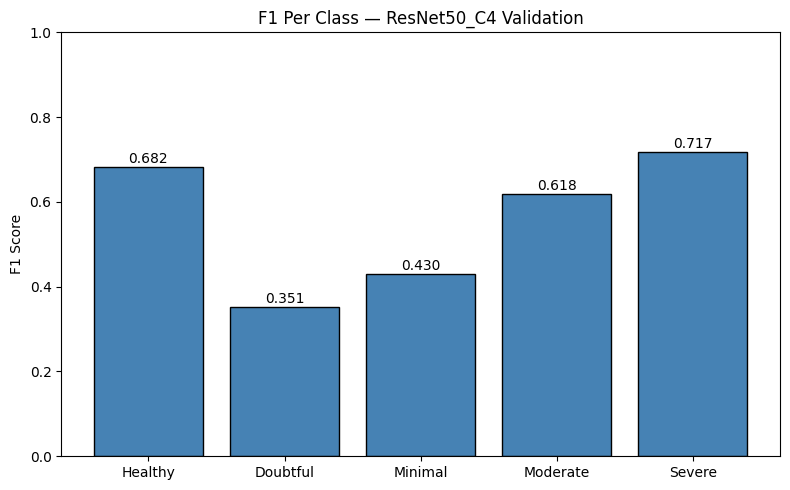

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# VALIDATION
# ══════════════════════════════════════════════════════════════════════════════
valid_generator.reset()
val_continuous = best_model.predict(valid_generator, verbose=1).reshape(-1)
val_true = valid_generator.labels

val_pred_labels = np.rint(np.clip(val_continuous, 0, 4)).astype(int)
val_scores = ordinal_score_matrix(val_continuous)

display_full_metrics(val_csv.iloc[0], val_true, val_pred_labels, MODEL_NAME, 'Validation')
plot_cm(val_true, val_pred_labels, f'Confusion Matrix — {MODEL_NAME} Validation', normalize=False)
plot_cm(val_true, val_pred_labels, f'Normalized CM — {MODEL_NAME} Validation', normalize=True)
plot_roc(val_true, val_scores, f'ROC Curves — {MODEL_NAME} Validation')
plot_f1(val_true, val_pred_labels, f'F1 Per Class — {MODEL_NAME} Validation')


## 10. Test Set Evaluation

Reload the best saved model and run the final evaluation on the independent test split.

In [18]:
resnet_model = tf.keras.models.load_model(save_model_ft, safe_mode=False, custom_objects={'accuracy': ordinal_accuracy})
predictions_resnet = resnet_model.predict(test_generator)
score_resnet = resnet_model.evaluate(test_generator, verbose=1, return_dict=True)
print('Test loss:', score_resnet['loss'])
print('Test mae:', score_resnet.get('mae'))
print('Test acc:', score_resnet.get('accuracy'))

104/104 [==============================] - 5s 40ms/step - loss: 0.5788 - mae: 0.5402 - accuracy: 0.5595
Test loss: 0.5788419246673584
Test mae: 0.5402276515960693
Test acc: 0.559495210647583


In [19]:
from sklearn.metrics import cohen_kappa_score, classification_report, balanced_accuracy_score

# ── Validation metrics ───────────────────────────────────────────────────────
valid_generator.reset()
valid_preds_for_report = model_ft.predict(valid_generator, verbose=0)
v_pred_values, v_pred_labels = ordinal_predictions_to_labels(valid_preds_for_report, CLASS_NAMES)
v_acc      = accuracy_score(valid_generator.labels, v_pred_labels)
v_bal_acc  = balanced_accuracy_score(valid_generator.labels, v_pred_labels)
v_mae      = float(np.mean(np.abs(valid_generator.labels - v_pred_values)))
v_qwk      = cohen_kappa_score(valid_generator.labels, v_pred_labels, weights='quadratic')
v_report   = classification_report(valid_generator.labels, v_pred_labels, target_names=CLASS_NAMES)

# ── Test metrics ─────────────────────────────────────────────────────────────
test_pred_values, test_pred_labels = ordinal_predictions_to_labels(predictions_resnet, CLASS_NAMES)
test_acc     = accuracy_score(test_generator.labels, test_pred_labels)
test_bal_acc = balanced_accuracy_score(test_generator.labels, test_pred_labels)
test_mae     = float(np.mean(np.abs(test_generator.labels - test_pred_values)))
test_qwk     = cohen_kappa_score(test_generator.labels, test_pred_labels, weights='quadratic')
test_report  = classification_report(test_generator.labels, test_pred_labels, target_names=CLASS_NAMES)

# ── Write eval_report.txt in the requested format ────────────────────────────
eval_report = (
    f'Test Accuracy: {test_acc:.4f}\n'
    f'Balanced Accuracy: {test_bal_acc:.4f}\n'
    f'MAE: {test_mae:.4f}\n'
    f'QWK: {test_qwk:.4f}\n\n'
    f'Validation classification report:\n{v_report}\n'
    f'Test classification report:\n{test_report}'
)

with open('eval_report.txt', 'w', encoding='utf-8') as f:
    f.write(eval_report)

print('Saved eval_report.txt')
print(f'\nValidation | Accuracy={v_acc:.4f}  Balanced={v_bal_acc:.4f}  MAE={v_mae:.4f}  QWK={v_qwk:.4f}')
print(f'Test       | Accuracy={test_acc:.4f}  Balanced={test_bal_acc:.4f}  MAE={test_mae:.4f}  QWK={test_qwk:.4f}')
print()
print(eval_report)


Saved eval_report.txt

Validation | Accuracy=0.5327  Balanced=0.5482  MAE=0.5650  QWK=0.7562
Test       | Accuracy=0.5592  Balanced=0.5694  MAE=0.5329  QWK=0.7800

Test Accuracy: 0.5592
Balanced Accuracy: 0.5694
MAE: 0.5329
QWK: 0.7800

Validation classification report:
              precision    recall  f1-score   support

     Healthy       0.72      0.65      0.68       328
    Doubtful       0.26      0.53      0.35       153
     Minimal       0.59      0.34      0.43       212
    Moderate       0.76      0.52      0.62       106
      Severe       0.73      0.70      0.72        27

    accuracy                           0.53       826
   macro avg       0.61      0.55      0.56       826
weighted avg       0.61      0.53      0.55       826

Test classification report:
              precision    recall  f1-score   support

     Healthy       0.77      0.67      0.71       639
    Doubtful       0.28      0.60      0.39       296
     Minimal       0.62      0.37      0.47      

104/104 [==============================] - 11s 105ms/step

  COMPREHENSIVE EVALUATION METRICS MATRIX
  Model : ResNet50_C4
  Split : Test
  Metric                                            Value
  ------------------------------------------------------------------------
  Overall Accuracy                                 0.5592
  Balanced Accuracy                                0.5694
  Mean Absolute Error (MAE)                        0.5329
  Macro ROC AUC (ordinal matrix)                   0.8648
  Quadratic Weighted Kappa (QWK)                   0.7800

  PER-CLASS BREAKDOWN
  ------------------------------------------------------------------------
  Class           Precision     Recall         F1    Support
  ------------------------------------------------------------------------
  Healthy            0.7652     0.6682     0.7135        639
  Doubtful           0.2828     0.6047     0.3854        296
  Minimal            0.6162     0.3736     0.4652        447
  Moderate           0

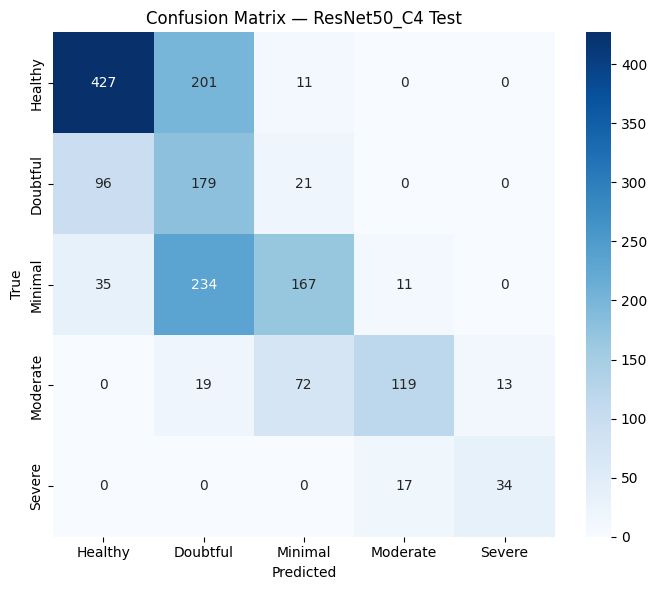

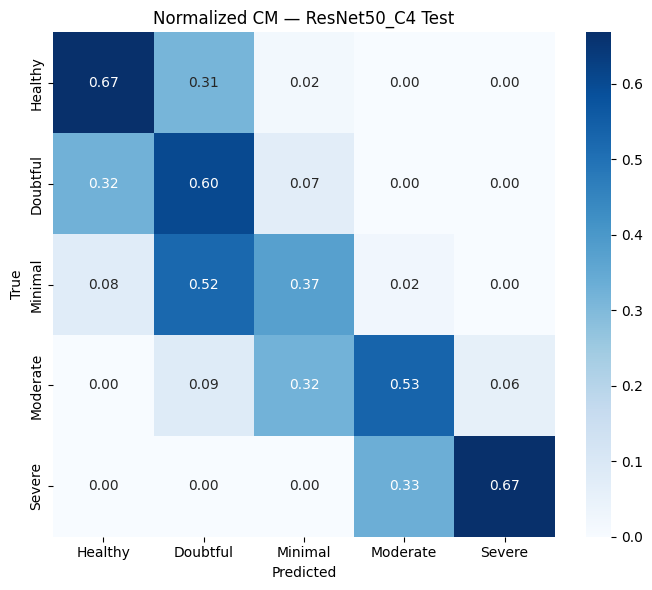

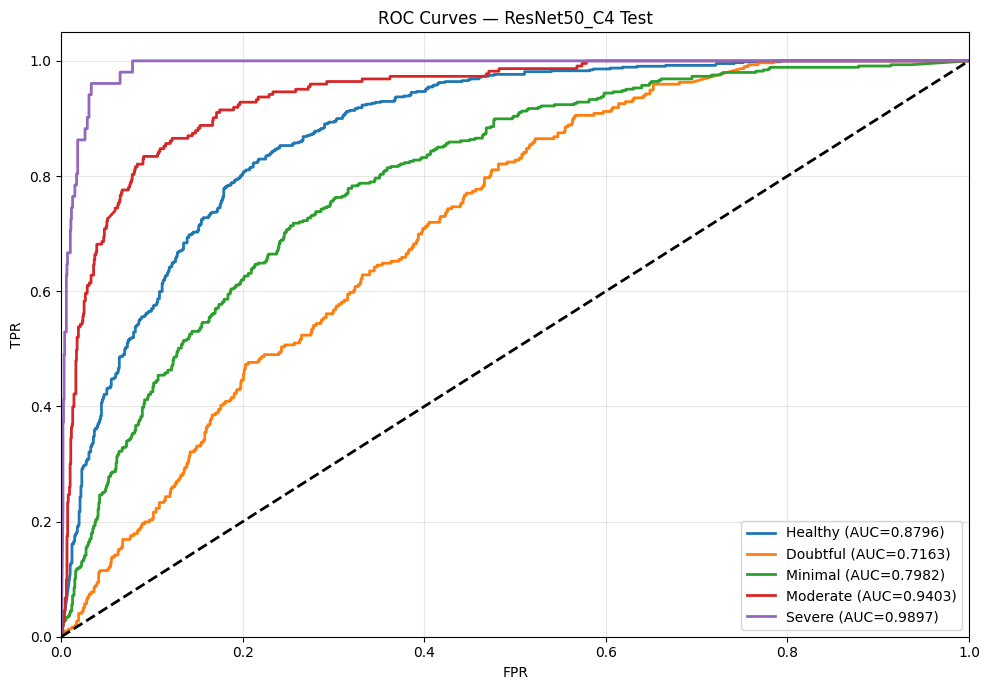

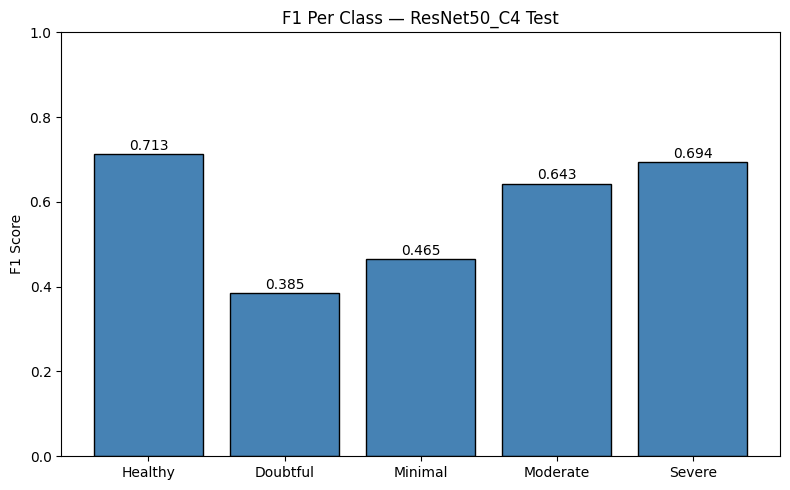

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# TEST
# ══════════════════════════════════════════════════════════════════════════════
test_generator.reset()
test_continuous = best_model.predict(test_generator, verbose=1).reshape(-1)
test_true = test_generator.labels

test_pred_labels = np.rint(np.clip(test_continuous, 0, 4)).astype(int)

test_scores = ordinal_score_matrix(test_continuous)

display_full_metrics(test_csv.iloc[0], test_true, test_pred_labels, MODEL_NAME, 'Test')
plot_cm(test_true, test_pred_labels, f'Confusion Matrix — {MODEL_NAME} Test', normalize=False)
plot_cm(test_true, test_pred_labels, f'Normalized CM — {MODEL_NAME} Test', normalize=True)
plot_roc(test_true, test_scores, f'ROC Curves — {MODEL_NAME} Test')
plot_f1(test_true, test_pred_labels, f'F1 Per Class — {MODEL_NAME} Test')


## 12. Model Interpretability & Visualization

Grad-CAM helps verify whether the model focuses on clinically relevant regions instead of irrelevant background patterns.

In [22]:
def make_gradcam_heatmap(grad_model, img_array, pred_index=None):
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = 0 if preds.shape[-1] == 1 else tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + tf.keras.backend.epsilon())
    return heatmap.numpy()

def save_and_display_gradcam(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap('jet')
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)
    superimposed_img = jet_heatmap * alpha + img
    return tf.keras.preprocessing.image.array_to_img(superimposed_img)

----test----
Grade 0-Healthy: 639 images, 38.59%
Grade 1-Doubtful: 296 images, 17.87%
Grade 2-Minimal: 447 images, 26.99%
Grade 3-Moderate: 223 images, 13.47%
Grade 4-Severe: 51 images, 3.08%
Test data - Healthy


/tmp/ipykernel_2096/2451040415.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap('jet')


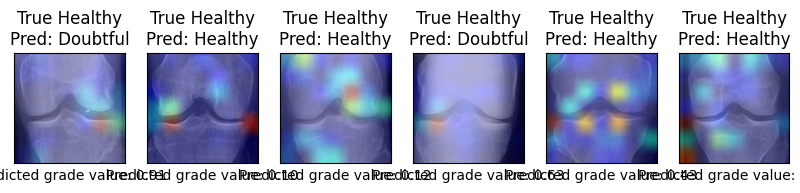

Test data - Doubtful


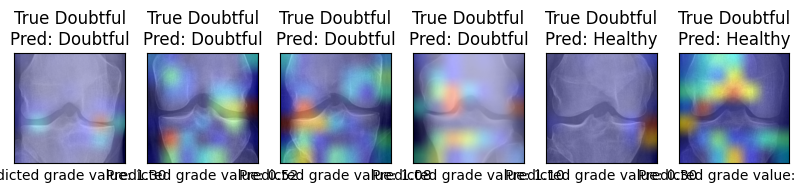

Test data - Minimal


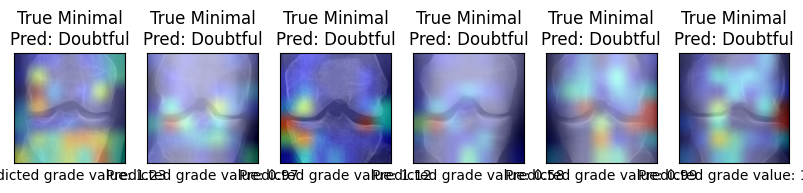

Test data - Moderate


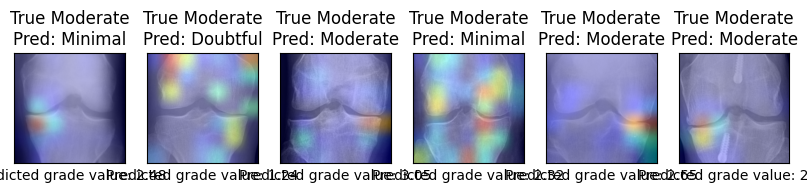

Test data - Severe


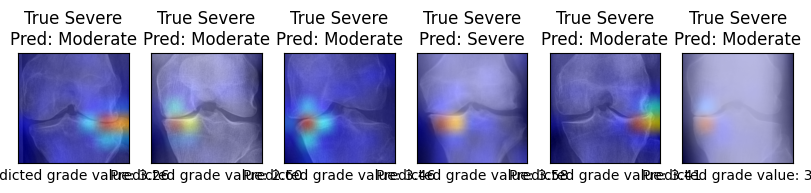

In [23]:
tests_data = get_classes(TEST_PATH, CLASS_NAMES, 'test')
resnet_backbone = resnet_model.get_layer('resnet50')
conv_output = resnet_backbone.get_layer('conv5_block3_out').output
x = resnet_model.layers[2](conv_output)
x = resnet_model.layers[3](x, training=False)
x = resnet_model.layers[4](x)
x = resnet_model.layers[5](x, training=False)
preds = resnet_model.layers[6](x)
grad_model = tf.keras.models.Model(inputs=resnet_backbone.input, outputs=[conv_output, preds])
gradcam_dir = 'gradcam_outputs'
os.makedirs(gradcam_dir, exist_ok=True)

for k, v in tests_data.items():
    print(f'Test data - {CLASS_NAMES[k]}')
    plt.figure(figsize=(10, 28))
    for i in range(6):
        img_path = os.path.join(TEST_PATH, str(k), v[i])
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img = tf.keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img.copy(), axis=0)
        img_array = tf.keras.applications.resnet50.preprocess_input(img_array)
        y_pred = resnet_model.predict(img_array, verbose=0)[0]
        heatmap = make_gradcam_heatmap(grad_model, img_array)
        image = save_and_display_gradcam(img, heatmap)
        image.save(os.path.join(gradcam_dir, f'{CLASS_NAMES[k]}_{i + 1}.png'))
        plt.subplot(1, 6, i + 1, xticks=[], yticks=[])
        plt.imshow(image)
        _, gradcam_pred_label = ordinal_predictions_to_labels(y_pred, CLASS_NAMES)
        plt.title(f'True {CLASS_NAMES[k]}\nPred: {CLASS_NAMES[gradcam_pred_label[0]]}')
        plt.xlabel(f'Predicted grade value: {float(np.asarray(y_pred).reshape(-1)[0]):.2f}')
    plt.show()